---
title: "Regional vs. Demand-Weighted Coverage"
toc: true
execute:
  enabled: true
image: image.png
---

When you set `threshold_for_coverage` in `.solve()`, lokigi reports **two** coverage columns in `solution_df`:

- `proportion_within_coverage_threshold` -- the share of **demand** (people) within the threshold. This is the metric MCLP optimises, and the one you'll want for most real decisions.
- `proportion_regions_within_coverage_threshold` -- the share of **regions** (e.g. LSOAs) within the threshold, counting every region equally regardless of how many people live there.

These two coincide whenever demand is uniform across regions -- including whenever you don't call `.add_demand()` at all, since `.solve()` then assumes every region has equal demand. In that case, it's safe to only think about one of them.

Once demand is genuinely uneven, though, the two figures can diverge -- and can even rank different site combinations as "best". This example shows exactly that, using the same Brighton dataset and demand as the [MCLP example](../mclp/index.ipynb), but at a smaller scale (fewer sites, a tighter threshold) where the two metrics visibly pull in different directions.

## Setting up the problem

Same sites, travel matrix, region geometry and demand data as the [MCLP example](../mclp/index.ipynb) -- but with a smaller `p` and tighter threshold, so the two coverage metrics have room to disagree.

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_demand(
    "../../../sample_data/brighton_demand.csv",
    demand_col="demand",
    location_id_col="LSOA"
    )

problem.add_sites(
    "../../../sample_data/brighton_sites_named.geojson",
    candidate_id_col="site"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

## Solving

We'll solve for just 2 sites with an 8-minute threshold -- a small enough problem that the two coverage metrics can disagree without either of them saturating near 100%.

In [2]:
solutions = problem.solve(
    objectives="mclp",
    p=2,
    threshold_for_coverage=8
    )

  0%|          | 0/15 [00:00<?, ?it/s]

## Comparing the two columns

`solve(objectives="mclp")` ranks solutions by `proportion_within_coverage_threshold` -- the demand-weighted figure -- so `show_solutions()` is already sorted by that column. Look at the top two rows alongside `proportion_regions_within_coverage_threshold`:

In [3]:
solutions.show_solutions(rounding=3)[[
    "site_names",
    "proportion_within_coverage_threshold",
    "proportion_regions_within_coverage_threshold",
    "weighted_average",
    ]].head(2)

,site_names,proportion_within_coverage_threshold,proportion_regions_within_coverage_threshold,weighted_average
0,"[Tulip (Site 3), Daisy (Site 4)]",0.782,0.745,5.944
1,"[Tulip (Site 3), Snowdrop (Site 6)]",0.737,0.758,6.687


### The same numbers, as headcounts

A percentage is compact, but "78.2% covered" doesn't say how many people that actually is. `demand_within_coverage_threshold`/`regions_within_coverage_threshold` are the literal headcount/region-count behind the two proportions above -- the same numerator `proportion_within_coverage_threshold` divides away, just kept.

In [4]:
solutions.show_solutions(rounding=1)[[
    "site_names",
    "demand_within_coverage_threshold",
    "regions_within_coverage_threshold",
    ]].head(2)

,site_names,demand_within_coverage_threshold,regions_within_coverage_threshold
0,"[Tulip (Site 3), Daisy (Site 4)]",257751.0,123
1,"[Tulip (Site 3), Snowdrop (Site 6)]",242829.0,125


`SiteProblem.total_demand` is the stable denominator behind the demand-weighted headcount -- useful for sanity-checking it independently.

In [5]:
top = solutions.solution_df.iloc[0]
implied = top["demand_within_coverage_threshold"] / problem.total_demand
print(f"demand_within_coverage_threshold / total_demand: {implied:.4f}")
print(f"proportion_within_coverage_threshold:            {top['proportion_within_coverage_threshold']:.4f}")

demand_within_coverage_threshold / total_demand: 0.7822
proportion_within_coverage_threshold:            0.7822


The top-ranked solution covers **more demand** (78.2% vs 73.7%), but the *second*-ranked solution actually covers **more regions** (75.8% vs 74.5%). 

MCLP -- correctly, per its textbook definition -- picked the solution that serves more people, even though it serves slightly fewer places.

We can pull out each "best" explicitly with `rank_on`, which is available on every `return_best_combination_*` method as well as the plotting methods:

In [6]:
demand_best = solutions.return_best_combination_site_names(
    rank_on="proportion_within_coverage_threshold"
    )

demand_best

['Tulip (Site 3)', 'Daisy (Site 4)']

In [7]:
regions_best = solutions.return_best_combination_site_names(
    rank_on="proportion_regions_within_coverage_threshold"
    )

regions_best

['Tulip (Site 3)', 'Snowdrop (Site 6)']

We can see we have two different combinations of sites here. Comparing the regions each one covers that the other doesn't shows why: the demand-weighted combination picks up 23 regions the region-best combination misses, averaging around 2,200 people each. The region-best combination picks up 25 regions the demand-weighted one misses -- slightly more of them -- but averaging only around 1,400 people each. Optimising for regions trades a smaller number of higher-population areas for a larger number of lower-population ones.

:::{.callout-note}
If you have never called `.add_demand()`, every region is assumed to have equal demand, and `demand_best`/`regions_best` above would always be identical -- there'd be nothing to trade off.
:::

## Visualising both

`plot_best_combination` accepts the same `rank_on` argument, so we can render each "best" combination.

### Best Solution by Demand

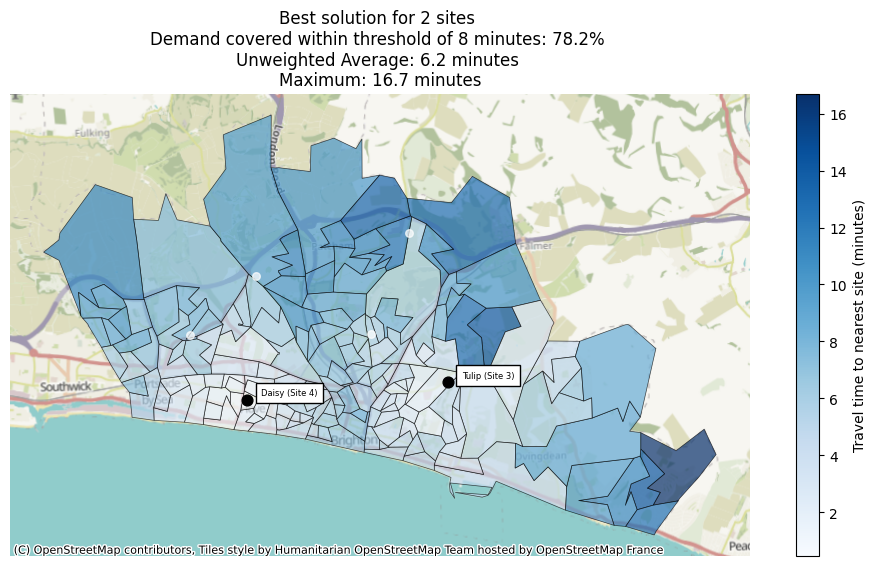

In [8]:
solutions.plot_best_combination(
    rank_on="proportion_within_coverage_threshold",
    title="default"
    );

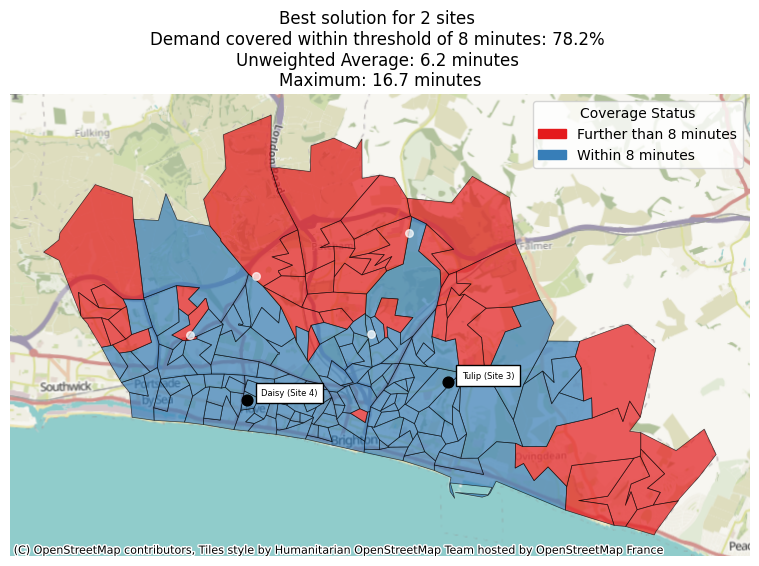

In [9]:
solutions.plot_best_combination(
    rank_on="proportion_within_coverage_threshold",
    title="default",
    plot_regions_not_meeting_threshold=True
    );

Here, while there are more regions not meeting the threshold and visually some very large areas of the map not meeting the threshold, we can see when comparing with the demand map that in general they are regions with low demand.

<Axes: >

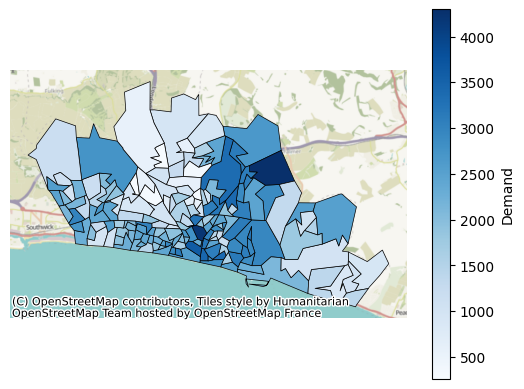

In [10]:
problem.plot_region_geometry_layer(plot_demand=True)

### Best Solution by Regions

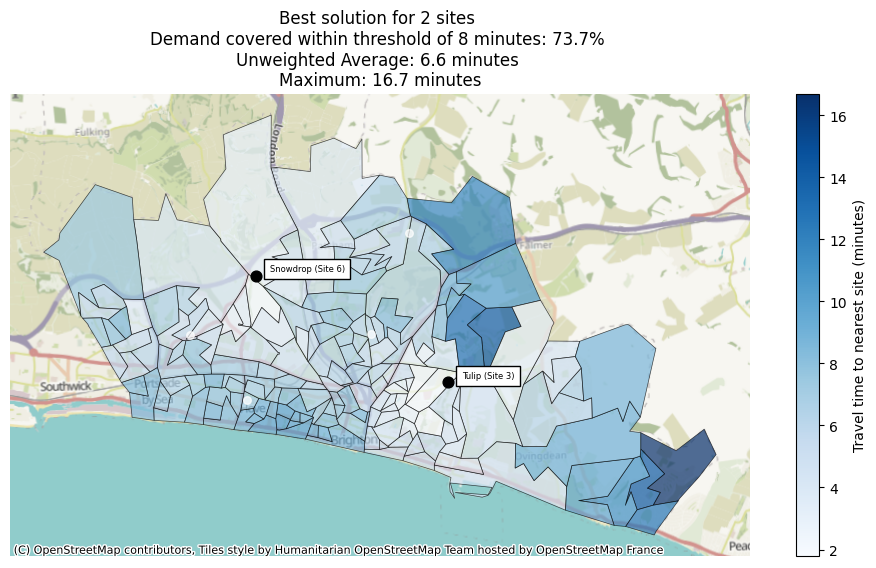

In [11]:
solutions.plot_best_combination(
    rank_on="proportion_regions_within_coverage_threshold",
    title="default"
    );

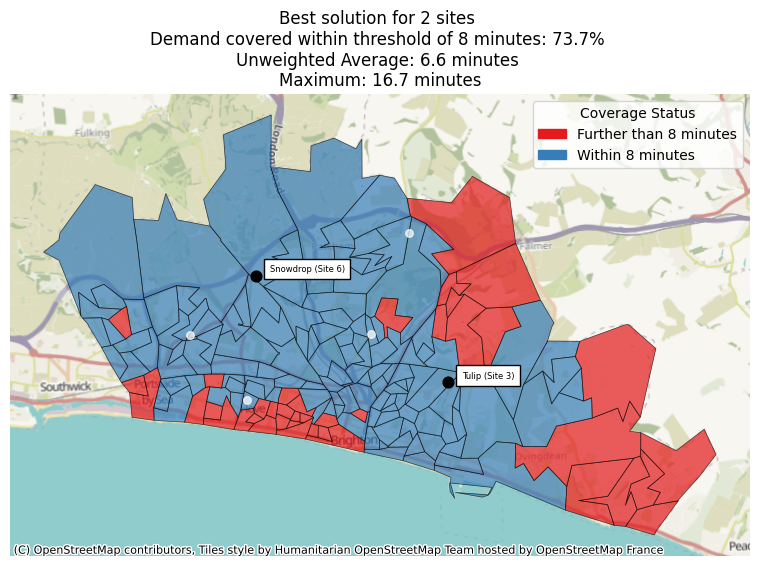

In [12]:
solutions.plot_best_combination(
    rank_on="proportion_regions_within_coverage_threshold",
    title="default",
    plot_regions_not_meeting_threshold=True
    );

Comparing this with the demand-aware proportion map, visually there appears to be less red on this map, but there is a swathe of red near the coast that coincides with high demand. 

<Axes: >

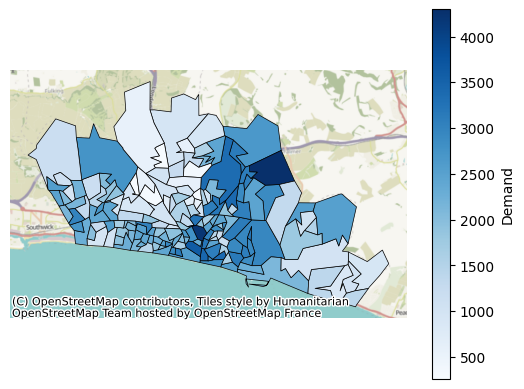

In [13]:
problem.plot_region_geometry_layer(plot_demand=True)

## Elsewhere in lokigi

The same naming rule applies wherever coverage is reported:

- Per-equity-band coverage splits the same way -- `coverage_by_equity_group` is demand-weighted, `coverage_regions_by_equity_group` counts regions. See the [equity example](../equity/index.ipynb).
- Secondary travel matrices (`add_secondary_travel_matrix`) get both variants too, suffixed `__<label>` -- see the [multiple travel matrices example](../multiple_travel_matrices/index.ipynb).
- Binary coverage can't tell two equally-covered regions apart if one of them shares its nearest site with far more competing demand -- see the [2SFCA accessibility example](../accessibility_2sfca/index.ipynb) for a metric that can.
- Both columns are `NaN`, not `0.0`, if `threshold_for_coverage` was never set -- "not measured" doesn't get confused with "nothing covered". The headcount columns follow the same rule.
- For the flip side of coverage -- how many people are *beyond* one or more thresholds, rather than within one -- see `beyond_thresholds` in the [population impact example](../population_impact/index.ipynb).

As a rule of thumb: reach for the demand-weighted (unqualified) column unless you have a specific reason to treat every region as equally important regardless of population.